# Unit 1 Assessment: Dataset 4 — Online Retail Transaction Analysis

## Objectives

- Load and inspect the Online Retail transaction dataset.
- Assess data quality before making changes.
- Clean and transform the data through a documented ETL process.
- Create meaningful measures, including line revenue.
- Use focused exploratory analysis and static visualisations to investigate product, country, and time patterns.
- Record findings, limitations, AI assistance, and questions for further investigation.

## Inputs and outputs

- Input: `Data_Sets/Online_Retail.csv`
- Output: `outputs/cleaned_online_retail.csv`
- Visualisations: one Matplotlib raw-versus-clean comparison, followed by Seaborn analytical charts.

This notebook runs from top to bottom because later cells depend on objects created earlier. The raw dataset remains available while I investigate and apply cleaning decisions. The analysis is descriptive: it identifies patterns in the data but does not claim to prove causation, profitability, or customer identity.

# Phase 1 — setup and extraction

### Business intent — growth and performance

>This notebook will start with a compelling idea.  There is a massive mysterious whale of a customer hiding in this dataset, and I am the man to find him and reel him in.  You will notice how this whale hunt, or investigation into the giant mystery customer dies during initial data investigation/exploration.  I have left the initial work in place, as it was this exploration of the dataset that revealed the truth to me, and it remains important early dataset analysis. After I realised my error, I had to pivot, and come up with a hypothesis to test that did not need a white whale.
>
>So what follows after is me creating this notebook for an imagined Commercial Director of an imagined UK-based online retailer. I am looking to understand their business, then to look for evidence of product performance, market value, activity over time, and possible underperformance. I will compare transaction volume with revenue rather than assuming that the busiest market is the most valuable.

> I can apply data analytics to this retail domain in several connected ways. Product-performance analysis shows which lines generate recorded revenue and which have seasonal shapes. Market comparison separates busy countries from valuable countries. Customer analysis can reveal concentrated or repeat relationships where identifiers permit it. Time analysis supports stock, staffing, and campaign planning. Underperformance analysis can flag products, markets, or periods that need a closer look. Future segmentation could distinguish domestic, international, and relationship-level purchasing patterns. Predictive analytics could later support demand forecasting, but this notebook deliberately remains descriptive.

> The immediate business challenge is that United Kingdom dominance, transaction noise, incomplete customer context, and an incomplete final December make it difficult to identify genuine international opportunities and plan for changing demand. I use the notebook to establish measured evidence before recommending action. A future AI pipeline opportunity would be to prioritise markets, products, or customer relationships for investigation, forecast demand from validated time patterns, and flag unusual changes. I do not claim to build that AI system here; I only identify the evidence it would need.

### Cell 1 — import the toolkit

> I load the libraries used for the analysis and give them familiar short names. Pandas works with table-shaped data; NumPy remains part of my normal toolkit; Matplotlib and Seaborn create the visualisations.

> I am consciously not using Plotly here. Static Matplotlib and Seaborn charts are more than sufficient for this assessment and for this dataset. Interactive charting would not add extra analytical value to the questions I am asking or hoping to answer, so I am keeping the visual work static, focused, and easy to reproduce. I have one mantra:
> > *“For every analysis cell, write the human question and metric in the Markdown above it. A chart is not a question by itself.”*

In [1]:
# I load the libraries used for the analysis and give them familiar short names.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I use a readable default style for the later Seaborn charts.
sns.set_theme(style="whitegrid")

### Cell 2 — load the raw file

> I load the supplied CSV into `df_raw`. I keep this first table unchanged so it remains my audit source throughout the notebook.

In [2]:
# I load the supplied CSV into an untouched raw table so later transformations remain reversible.
df_raw = pd.read_csv("../Data_Sets/Online_Retail.csv")
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Cell 3 — establish the starting point

> I inspect the first rows, shape, column names, and data types before I make any changes. This gives me a visible starting point for the later cleaning comparison.

In [3]:
# I establish the starting shape, fields, and data types before changing anything.
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
display(df_raw.head())
df_raw.info()

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 69.3 MB


# Phase 2 — investigate data quality before deciding

### Cell 4 — quality inventory

> I count missing values, duplicate rows, non-positive quantities, non-positive prices, and cancellation-style invoice numbers. These are signals to investigate, not automatic instructions to delete rows.

> I also check how the customer IDs are distributed. This dataset is widely documented as having a large number of missing customer IDs, so the missing-value count is the first thing I want to see.

In [29]:
# I treat invoice numbers as text so I can inspect the cancellation-style C prefix.
invoice_text = df_raw["InvoiceNo"].astype("string")

# These counts describe quality signals; they don't decide the cleaning rules by themselves.
print("Missing values:")
display(df_raw.isna().sum())
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Quantity <= 0:", (df_raw["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df_raw["UnitPrice"] <= 0).sum())
print("Invoice numbers starting with C:",
      invoice_text.str.startswith("C", na=False).sum())

# The missing-value count above surprised me, so I check how the customer IDs are spread.
print("\nDistinct customer IDs:", df_raw["CustomerID"].nunique())
print("Rows per customer ID, five largest:")
display(df_raw["CustomerID"].value_counts().head(5))

Missing values:


InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

Exact duplicate rows: 5268
Quantity <= 0: 10624
UnitPrice <= 0: 2517
Invoice numbers starting with C: 9288

Distinct customer IDs: 4372
Rows per customer ID, five largest:


CustomerID
15287    135101
17841      7983
14911      5903
14096      5128
12748      4642
Name: count, dtype: int64

### Analysis — the customer ID anomaly

This is not what I expected at all. This dataset is widely documented as having around 135,000 missing customer IDs. This copy has none. Every single row carries a customer number, and `CustomerID` has been stored as a whole number, which is only possible if nothing is missing.

The distribution shows what happened:

> - **Distinct customer IDs:** 4,372
> - **Rows carrying `15287`:** 135,101
> - **Rows carrying the next largest ID, `17841`:** 7,983

One identifier holds roughly a quarter of the entire file and is about seventeen times larger than the next one down. The documented missing-value count and the number of rows sitting on `15287` are near enough identical.

I want to see this rather than infer it, so I plot it next.

### Cell 4A — visualise the customer ID distribution

> The counts above show one identifier dominating, but five rows of a table do not show me the shape of the whole customer base. I plot every customer by rank against the number of rows they carry. I use a logarithmic scale because the values span several orders of magnitude.

> This is the test: if `15287` were a real customer, however large, it should sit at the top of a smooth curve alongside the other big buyers. I want to see whether it does.

,Rank,Rows,CustomerID
0,1,135101,15287
1,2,7983,17841
2,3,5903,14911
3,4,5128,14096
4,5,4642,12748


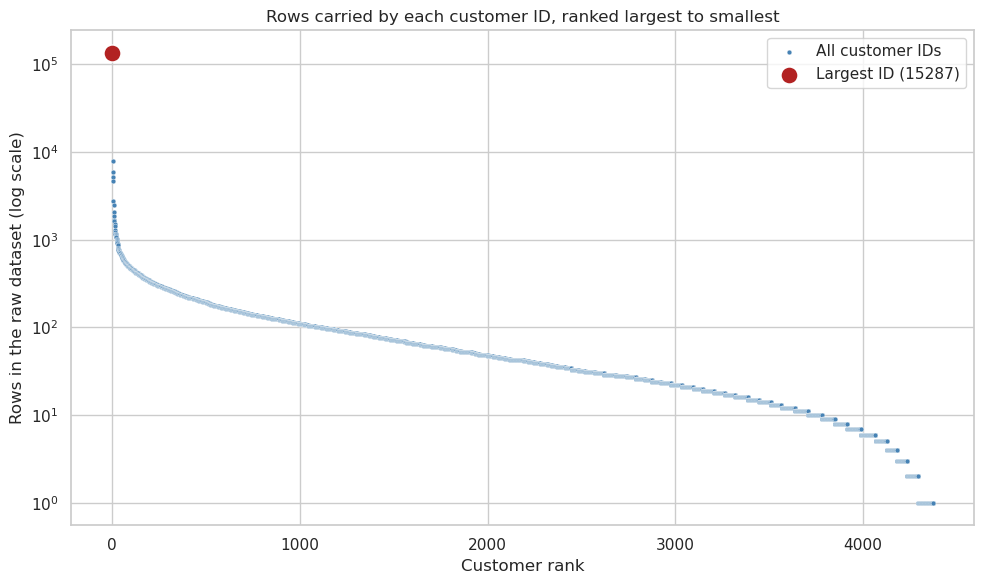

In [5]:
# I count the rows carried by every customer ID, largest first.
customer_row_counts = df_raw["CustomerID"].value_counts()

# I build a small table so each customer's rank and row count can be plotted together.
customer_rank_table = pd.DataFrame({
    "Rank": range(1, len(customer_row_counts) + 1),
    "Rows": customer_row_counts.values,
    "CustomerID": customer_row_counts.index,
})

display(customer_rank_table.head())

plt.figure(figsize=(10, 6))

# I plot every customer as a small point to show the shape of the distribution. I adore Seaborn.
sns.scatterplot(
    data=customer_rank_table,
    x="Rank",
    y="Rows",
    s=12,
    color="steelblue",
    label="All customer IDs",
)

# I mark the top-ranked identifier so its distance from the rest is obvious.
sns.scatterplot(
    data=customer_rank_table.head(1),
    x="Rank",
    y="Rows",
    s=150,
    color="firebrick",
    label="Largest ID (15287)",
)

# I use a logarithmic scale because the row counts span several orders of magnitude.
plt.yscale("log")
plt.title("Rows carried by each customer ID, ranked largest to smallest")
plt.xlabel("Customer rank")
plt.ylabel("Rows in the raw dataset (log scale)")
plt.legend()
plt.tight_layout()

# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_customer_id_ghost.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis — the ghost whale

Well, there it is.

>Every real customer sits on a smooth curve that decays steadily from a few thousand rows down to a handful. That is what a customer base looks like. The top-ranked identifier is not at the top of that curve. It is detached from it, sitting well clear of the customer ranked below it.

>A point that does not belong to the distribution it is plotted in is not an unusually good customer. It is a container. A placeholder for something else.

>I spent a considerable stretch early on in this project hunting that point as though it were a real buyer — an enormous account worth understanding, worth chasing. This chart is where the whale turned out to be a ghost. `15287` is not a customer at all. It is every transaction whose customer was never recorded, swept together under one invented number by whoever prepared this copy of the data, long before it reached me.

>**What this changes, and what it does not.** Revenue, product, country, and time analysis are unaffected. Those transactions are real sales, with real dates, real prices, and real destinations — it is only the identity of the buyer that was never captured. Anything counted *per customer* is affected, so from here on I count identified customers and say so, rather than pretending the total is complete. 

>This notebook will now flow on as if nothing happened, but something has happpened.  I have just spent half a day rethinking what I want to understand here, what I want to examine, and how that examination could be of value to someone who is not a student learning to wrangle data on a fast paced DA bootcamp.  I have learned however that exploring and understanding what it is you are investigating is just as important as any planned investigation itself.

### Cell 5 — inspect cancellations and negative quantities

> Negative quantities may represent cancellations, returns, or another adjustment. I compare the `C`-invoice group with negative quantities that do not have the `C` prefix. I keep the meaning of the second group open until the displayed rows and descriptions give me enough evidence.

In [6]:
# I identify cancellation-style invoices and negative quantities separately.
cancellation_mask = invoice_text.str.startswith("C", na=False)
negative_quantity_mask = df_raw["Quantity"] < 0

# This mask isolates negative quantities that do not have the C invoice prefix.
other_negative_mask = negative_quantity_mask & ~cancellation_mask

print("Negative quantities with a C invoice:",
      (negative_quantity_mask & cancellation_mask).sum())
print("Negative quantities without a C invoice:",
      other_negative_mask.sum())

# I display sample exception rows so I can investigate their meaning before cleaning.
display(df_raw.loc[
    other_negative_mask,
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].head(20))

Negative quantities with a C invoice: 9288
Negative quantities without a C invoice: 1336


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
2406,536589,21777,NaN,-10,0.0,United Kingdom
4347,536764,84952C,NaN,-38,0.0,United Kingdom
7188,536996,22712,NaN,-20,0.0,United Kingdom
7189,536997,22028,NaN,-20,0.0,United Kingdom
7190,536998,85067,NaN,-6,0.0,United Kingdom
7192,537000,21414,NaN,-22,0.0,United Kingdom
7193,537001,21653,NaN,-6,0.0,United Kingdom
7195,537003,85126,NaN,-2,0.0,United Kingdom
7196,537004,21814,NaN,-30,0.0,United Kingdom
7197,537005,21692,NaN,-70,0.0,United Kingdom


### Analysis — what the negative-quantity output tells me

This tells me that every `C` invoice row also has a negative quantity. In this dataset, the `C` prefix is therefore a strong indicator of cancellations or returns. However, something sticks out:

> - **Total negative-quantity rows:** 10,624
> - **Negative-quantity rows with no C prefix:** 1,336

Those 1,336 rows are the group I need to investigate next. They do not fit the obvious cancellation pattern. The visible descriptions suggest returns-related or stock-adjustment records rather than ordinary sales, but the exact business process behind every row remains unproven.

### Cell 6 — inspect non-product stock codes

> Some stock codes do not begin with a digit. I inspect their descriptions and frequencies because the group can contain postage, fees, adjustments, vouchers, or product-like rows. The pattern identifies a group for investigation; it does not prove that every row should be removed.

In [7]:
# I standardise stock codes as trimmed text before testing their first character.
stock_text = df_raw["StockCode"].astype("string").str.strip()

# This mask identifies stock codes that do not begin with a digit for investigation.
non_numeric_mask = ~stock_text.str.match(r"^\d", na=False)

# I inspect both the frequency of each code and a sample of the related rows.
non_product_rows = df_raw.loc[non_numeric_mask]
print("Rows with non-numeric-leading stock codes:", len(non_product_rows))
display(non_product_rows["StockCode"].value_counts().head(20))
display(non_product_rows[
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].head(20))

Rows with non-numeric-leading stock codes: 2995


StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
gift_0001_50       4
PADS               4
gift_0001_40       3
B                  3
DCGS0076           2
Name: count, dtype: int64

,StockCode,Description,Quantity,UnitPrice
45,POST,POSTAGE,3,18.00
141,D,Discount,-1,27.50
386,POST,POSTAGE,1,15.00
1123,POST,POSTAGE,1,18.00
1423,C2,CARRIAGE,1,50.00
1814,DOT,DOTCOM POSTAGE,1,569.77
2239,M,Manual,1,1.25
2250,M,Manual,1,18.95
3041,DOT,DOTCOM POSTAGE,1,607.49
4406,BANK CHARGES,Bank Charges,1,15.00


### Analysis — the mixed non-numeric population

Mmm? Non-numeric stock-code rows are a small proportion of the dataset by row count, but their revenue effect is not uniform. The visible groups include postage, carriage, fees, discounts, samples, vouchers, and descriptions that appear product-related. I will not remove this population as one blanket category. I need the remaining price and description evidence before recording the final ETL rules.

### Cell 7 — inspect prices, descriptions, and duplicates

> I separate zero prices, negative prices, missing descriptions, and duplicates. Keeping these conditions visible helps me explain the cleaning rules rather than hiding them inside a large unexplained mask.

In [8]:
# I keep each condition as a named mask so I can count and inspect it separately.
zero_price_mask = df_raw["UnitPrice"] == 0
negative_price_mask = df_raw["UnitPrice"] < 0
missing_description_mask = df_raw["Description"].isna()

print("UnitPrice == 0:", zero_price_mask.sum())
print("UnitPrice < 0:", negative_price_mask.sum())
print("Missing Description:", missing_description_mask.sum())

# I combine the visible conditions only for a focused inspection table.
display(df_raw.loc[
    zero_price_mask | negative_price_mask | missing_description_mask,
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(30))

UnitPrice == 0: 2515
UnitPrice < 0: 2
Missing Description: 1454


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


### Analysis — the price and description evidence

> I am happier now. The zero-price rows, the two negative-price rows, and the missing descriptions occur within the non-positive-price population rather than forming an additional positive-price group. For the primary paid-sales analysis, I will exclude non-positive-price rows and will not impute missing descriptions. These rows remain in the raw dataset for audit and separate investigation.

### Decision checkpoint — investigation and decisions

> The raw dataset will be retained unchanged as the audit source. The working analysis table will represent paid product sales rather than every transaction-like row.
>
> Exact duplicate rows will be excluded from the working analysis table to avoid double-counting identical records.
>
> C-invoice cancellations and the 1,336 negative-quantity rows without C invoices will be treated separately from gross product sales. Their evidence points to cancellations, damages, checks, or other adjustments rather than normal paid sales.
>
> Zero-price rows and the two negative-price rows will be excluded from paid-sales metrics because they cannot represent ordinary paid product revenue. Missing descriptions will not be imputed for the core sales analysis. These rows will remain separately available through the audit source and excluded view.
>
> Operational and financial non-numeric stock-code groups—including postage, carriage, discounts, samples, bank charges, fees, commissions, bad debt, and manual adjustments—will be excluded from product-level analysis. Product-like non-numeric codes will be retained where they represent positive-price product lines.
>
> I make these scope decisions for analysing paid product, market, customer, and time patterns. They do not claim that the excluded rows are meaningless; they place them outside the primary sales-analysis table.